In [4]:
!pip install shap numpy --upgrade

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.3 MB 6.9 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.3 MB 7.6 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.3 MB 7.5 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.3 MB 7.5 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.3 MB 7.9 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 6.6 MB/s eta 0:00:01
   ------------------------------- -------- 9.7/12.3 MB 7.1 MB/s eta 0:00:01
   ---------------------------------- ----- 10.5/12.3 MB 6.7 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
    --------------------------------------- 0.8/38.1 MB 4.1 MB/s eta 0:00:10
   - -----

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ============================================================================
# 1. ORTAM HAZIRLIĞI, VERİ NORMALİZASYONU VE MODEL EĞİTİMİ
# ============================================================================
import json
import random
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import shap

# Grafik tasarımları
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("1. Adım: Veriler py150 formatında okunuyor...")
ast_verileri = []
with open("archive/py150/python100k_train.json", "r") as f:
    for i, satir in enumerate(f):
        if i >= 5000:  # SHAP hesaplamaları ağır olduğu için 5000 veri idealdir
            break
        ast_verileri.append(json.loads(satir))

df = pd.DataFrame({"ast_nodes": ast_verileri})
df["label"] = 0 

# Hızlı mutation (Hata üretme) fonksiyonu
def ast_boz(ast_liste):
    bozuk_ast = json.loads(json.dumps(ast_liste))
    if len(bozuk_ast) > 2:
        secilen_index = random.randint(1, len(bozuk_ast) - 1)
        hata_turu = random.choice(["tip_degistir", "cocuk_sil", "deger_sil"])
        if hata_turu == "tip_degistir":
            bozuk_ast[secilen_index]["type"] = "HataliDugum"
        elif hata_turu == "cocuk_sil":
            if "children" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["children"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum" 
        elif hata_turu == "deger_sil":
            if "value" in bozuk_ast[secilen_index]: del bozuk_ast[secilen_index]["value"]
            else: bozuk_ast[secilen_index]["type"] = "HataliDugum"
    return bozuk_ast

df_bozulacaklar = df.sample(frac=0.5, random_state=42).copy()
df_bozulacaklar["ast_nodes"] = df_bozulacaklar["ast_nodes"].apply(ast_boz)
df_bozulacaklar["label"] = 1  

final_df = pd.concat([df, df_bozulacaklar], ignore_index=True)
df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# NLP Önişleme ve Normalizasyon (Düğümleri metne çevirme)
df['clean_ast_text'] = df['ast_nodes'].apply(lambda x: " ".join([d.get("type", "") for d in x]))

# TF-IDF Vektörleştirme (Kelimeleri matematiksel frekansa çevirme)
vectorizer = TfidfVectorizer(max_features=1000, lowercase=True)
X_transformed = vectorizer.fit_transform(df['clean_ast_text'])
y = df['label']

# Model Eğitimi
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_transformed, y)
feature_names = vectorizer.get_feature_names_out()

print("🚀 Veriler hazırlandı ve model eğitildi. SHAP analizine geçilebilir!")

1. Adım: Veriler py150 formatında okunuyor...
🚀 Veriler hazırlandı ve model eğitildi. SHAP analizine geçilebilir!


c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 7500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7500 when initializing the masker.


📊 Grafik 1: SHAP Summary Plot (Arı Kovanı Grafiği)


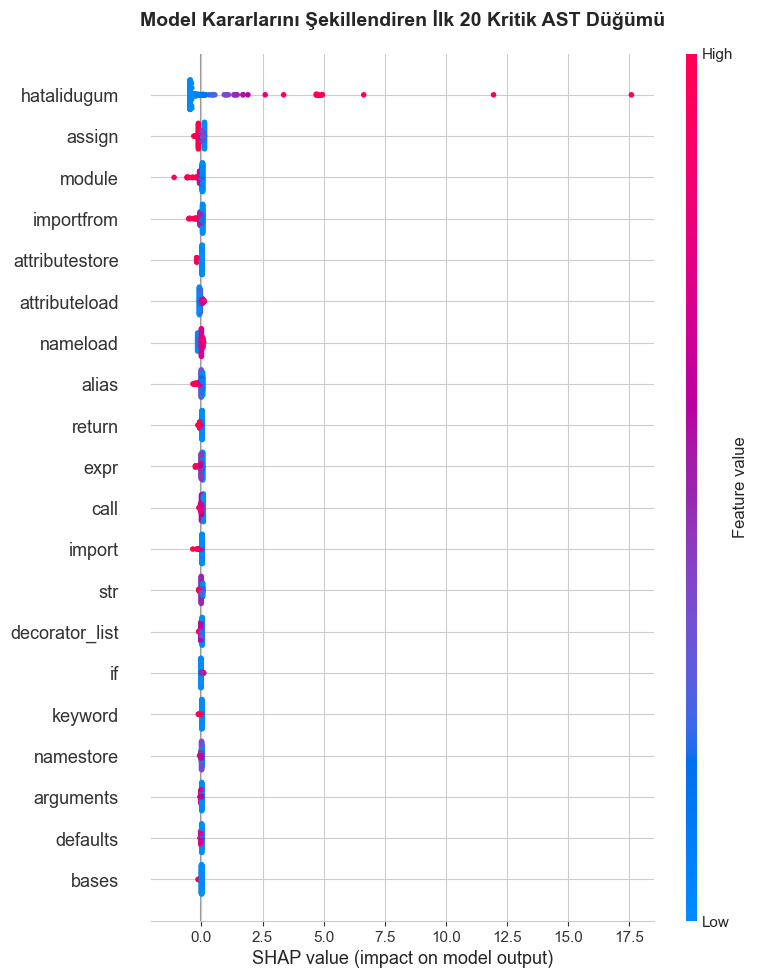

In [6]:
# ============================================================================
# 2. KÜRESEL (GLOBAL) SHAP ANALİZİ - MODELİN GENEL ZEKİSİ
# ============================================================================
# Arka plan için verinin yoğunluğunu hesaplayan LinearExplainer kuruyoruz
explainer = shap.LinearExplainer(model, X_transformed, feature_perturbation="interventional")

# Analizin hızlı bitmesi için ilk 300 satırı incelemeye alıyoruz
X_sample = X_transformed[:300].toarray()
shap_values = explainer(X_sample)

print("📊 Grafik 1: SHAP Summary Plot (Arı Kovanı Grafiği)")
# Bu grafik her bir düğümün kararı pozitif mi negatif mi etkilediğini renklerle (kırmızı/mavi) gösterir.
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
plt.title("Model Kararlarını Şekillendiren İlk 20 Kritik AST Düğümü", fontsize=14, fontweight='bold', pad=20)
plt.show()

📊 Grafik 2: Ortalama Mutlak SHAP Değerleri


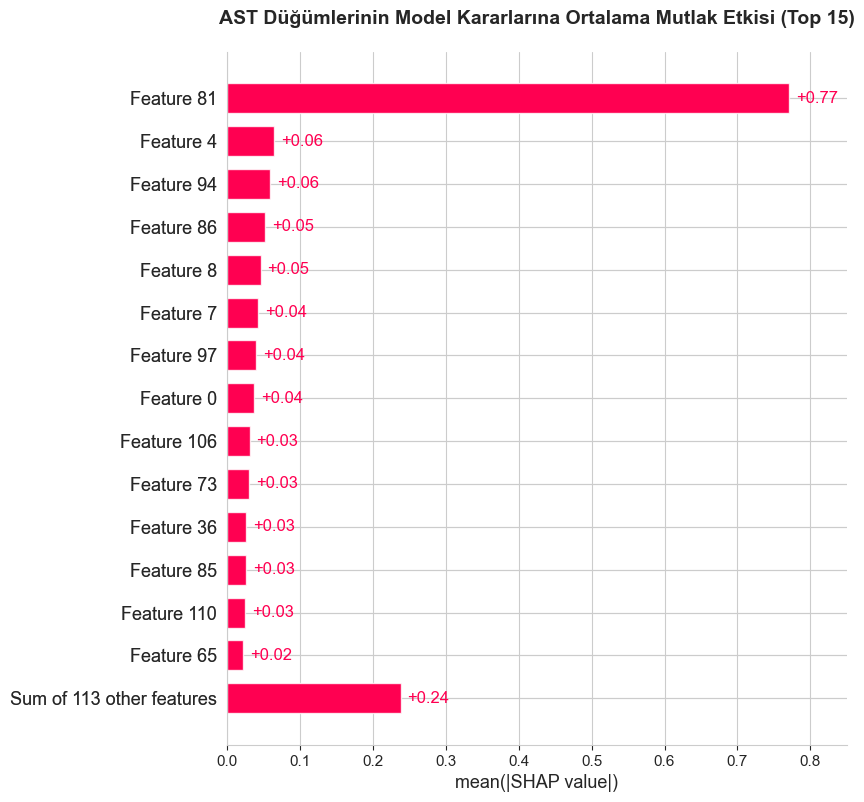

In [7]:
# ============================================================================
# 3. DÜĞÜMLERİN ORTALAMA ETKİ BÜYÜKLÜKLERİ (BAR PLOT)
# ============================================================================
print("📊 Grafik 2: Ortalama Mutlak SHAP Değerleri")
plt.figure(figsize=(12, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("AST Düğümlerinin Model Kararlarına Ortalama Mutlak Etkisi (Top 15)", fontsize=14, fontweight='bold', pad=20)
plt.show()

🎯 İncelenen Kodun Veri Setindeki İndeksi: 1
📝 Kodun Ham AST Dizilimi:
Module ImportFrom alias ImportFrom alias ImportFrom alias ImportFrom alias alias ImportFrom alias ImportFrom alias alias ImportFrom alias ImportFrom a...

📊 Grafik 3: Waterfall Plot (Sebebini Açıklama Terazisi)


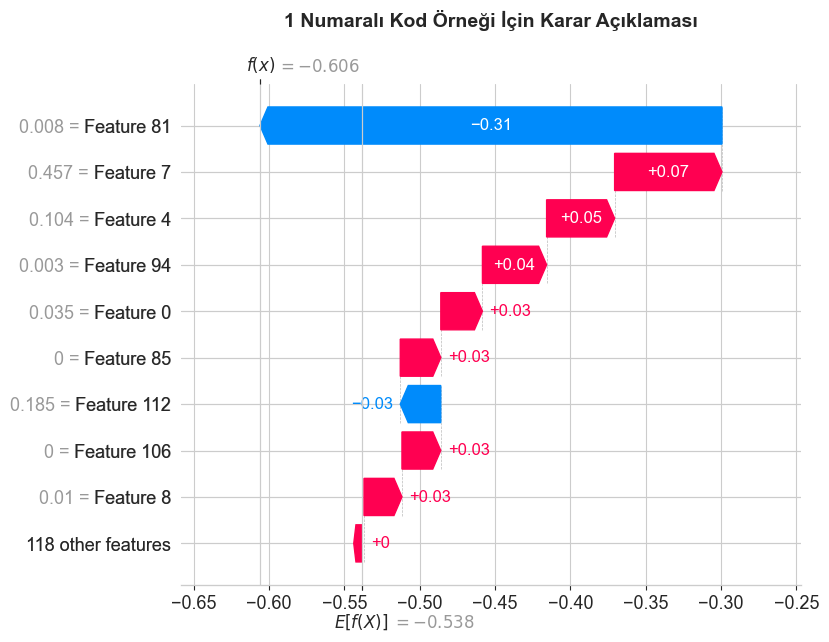

In [8]:
# ============================================================================
# 4. YEREL (LOCAL) ANALİZ - TEK BİR KODUN HATASINI AÇIKLAMA
# ============================================================================
# Veri setindeki ilk hatalı (label=1) örneğin indeksini bulalım
hatali_ornek_index = df[df['label'] == 1].index[0]

print(f"🎯 İncelenen Kodun Veri Setindeki İndeksi: {hatali_ornek_index}")
print(f"📝 Kodun Ham AST Dizilimi:\n{df['clean_ast_text'].iloc[hatali_ornek_index][:150]}...\n")

print("📊 Grafik 3: Waterfall Plot (Sebebini Açıklama Terazisi)")
# Bu grafik, baz çizgiden başlayarak hangi düğümlerin kodu "Hatalı" (sağa doğru) 
# veya "Hatasız" (sola doğru) ittiğini adım adım gösterir.
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values[hatali_ornek_index], max_display=10, show=False)
plt.title(f"{hatali_ornek_index} Numaralı Kod Örneği İçin Karar Açıklaması", fontsize=14, fontweight='bold', pad=20)
plt.show()